In [1]:
# selectia datelor. 
#filtram doar anii 2014-2026, deoarece se foloseste acelasi motor v6

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print('PASUL 1: Incarcare fisiere csv')

#incarcam datele brute din fisierele csv in variabile

#rezultate individuale ale fiecarui pilot pe cursa
df_results = pd.read_csv('results.csv')

#informatii generale despre curse si constructori
df_races = pd.read_csv('races.csv')
df_constructors = pd.read_csv('constructors.csv')

#info personale despre piloti
df_drivers = pd.read_csv('drivers.csv')

#motivul pt care un pilot a terminat cursa
df_status = pd.read_csv('status.csv')

#rezultate de la calificari
df_qualifying = pd.read_csv('qualifying.csv')

#punctele si pozitia pilotilor si construcxtorilor in campionat
df_driver_standings = pd.read_csv('driver_standings.csv')
df_constructor_standings = pd.read_csv('constructor_standings.csv')

#timpii si tururile in c›are pilotii au oprit la boxe
df_pit_stops = pd.read_csv('pit_stops.csv')

#rezultatele curselor de sprint
df_sprint = pd.read_csv('sprint_results.csv')

print('PASUL 2: Filtrare era V6 turbo hybrid (2014-2026)')

#folosim copy pt a crea un obiect nou si independent in memorie
#pastram doar coloanele de care avem nevoie
races_modern = df_races[df_races['year'] >= 2014][['raceId', 'year', 'name', 'date', 'round', 'circuitId']].copy()

#redenumim coloanele generice
races_modern.rename(columns={'name': 'race_name', 'date': 'race_date'}, inplace=True)

#inlocuim valorile lipsa (\N) cu NaN pt ca pandas sa le recunoasca
races_modern.replace({'\\N': np.nan}, inplace=True)

print(f' -> {len(races_modern)} curse din perioada 2014-2026')


#unirea tabelelor

df = pd.merge(df_results, races_modern, on='raceId', how='inner')
df = pd.merge(df, df_constructors[['constructorId', 'name']], on='constructorId', how='left')
df.rename(columns={'name': 'team_name'}, inplace=True)
df = pd.merge(df, df_drivers[['driverId', 'driverRef', 'dob', 'nationality']], on='driverId', how='left')
df = pd.merge(df, df_status[['statusId', 'status']], on='statusId', how='left')
df.replace({'\\N': np.nan}, inplace=True)

print(f' -> {len(df)} inregistrari dupa unirea tabelelor')

#afisam cateva linii de test pt a verifica ca datele s au unit corect
df[['raceId', 'year', 'race_name', 'team_name', 'driverRef', 'grid', 'positionOrder', 'status']].head()


PASUL 1: Incarcare fisiere csv
PASUL 2: Filtrare era V6 turbo hybrid (2014-2026)
 -> 274 curse din perioada 2014-2026
 -> 5215 inregistrari dupa unirea tabelelor


,raceId,year,race_name,team_name,driverRef,grid,positionOrder,status
0,900,2014,Australian Grand Prix,Mercedes,rosberg,3,1,Finished
1,900,2014,Australian Grand Prix,McLaren,kevin_magnussen,4,2,Finished
2,900,2014,Australian Grand Prix,McLaren,button,10,3,Finished
3,900,2014,Australian Grand Prix,Ferrari,alonso,5,4,Finished
4,900,2014,Australian Grand Prix,Williams,bottas,15,5,Finished


In [2]:
#preprocesarea datelor

print('Preprocesare date principale')

#convertim coloanele care ar trebui sa contina nr din string in format numeric 
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')
df['points'] = pd.to_numeric(df['points'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

#convertim coloanele cu date calendaristice in obiecte de tip 'datetime' pt a face calcule temporale ulterior
df['race_date'] = pd.to_datetime(df['race_date'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

#eliminam randurile in care lipsesc date critice pt analiza
df.dropna(subset=['grid', 'positionOrder'], inplace=True)

#pastram doar pilotii care pornesc din grid
df = df[df['grid'] > 0]

print(f' -> {len(df)} afisari valide dupa curatare')

#verificam daca mai exista goluri in anumite coloane
print('\nNumar de val lipsa pe coloane:')
print(df[['grid', 'positionOrder', 'dob', 'status']].isnull().sum())

Preprocesare date principale
 -> 5116 afisari valide dupa curatare

Numar de val lipsa pe coloane:
grid             0
positionOrder    0
dob              0
status           0
dtype: int64


In [3]:
#construim perechi de coechipieri
print('Construire perechi coechipieri')

#analizam doar curse in care ambii piloti a unei echipe au participat la cursa
driver_counts = df.groupby(['raceId', 'team_name'])['driverRef'].transform('count')
df_pairs = df[driver_counts == 2].copy()

#sortam datele 
df_pairs = df_pairs.sort_values(by=['raceId', 'team_name', 'positionOrder'])

#cream variabila tinta
df_pairs['beat_teammate'] = (df_pairs.groupby(['raceId', 'team_name']).cumcount() == 0).astype(int)

#afisam cate randuri au ramas dupa filtrare
print(f' -> {len(df_pairs)} inregistrari')

#verificam distributia castigatorilor (1) si pierzatorilor(2)
print(' -> Distributia clasei tinta:')
print(df_pairs['beat_teammate'].value_counts())

Construire perechi coechipieri
 -> 5050 inregistrari
 -> Distributia clasei tinta:
beat_teammate
1    2525
0    2525
Name: count, dtype: int64


In [4]:
#prepocesare calificari
print('Preprocesare date calificari')

#inlocuim valorile lipsa (\N) cu NaN pt ca pandas sa le recunoasca
df_qualifying.replace({'\\N': np.nan}, inplace=True)

#definim o functie pt a transforma timpul de la calificari din formatul 'm:ss.mmm' in secunde
def time_to_seconds(t):
    if pd.isnull(t) or t == '':
        return np.nan
    try:
        parts = str(t).split(':')
        return float(parts[0]) * 60 + float(parts[1]) if len(parts) == 2 else float(parts[0])
    except:
        return np.nan
    
for col in ['q1', 'q2', 'q3']:
    df_qualifying[f'{col}_sec'] = df_qualifying[col].apply(time_to_seconds)

df_qualifying['best_quali_time'] = df_qualifying[['q1_sec', 'q2_sec', 'q3_sec']].min(axis=1)
df_qualifying['position'] = pd.to_numeric(df_qualifying['position'], errors='coerce')

#extragem doar coloanele relevante pentru analiza
df_quali_clean = df_qualifying[['raceId', 'driverId', 'position', 'best_quali_time']].copy()

#redenumim coloana position pt claritate
df_quali_clean.rename(columns={'position': 'quali_position'}, inplace=True)

print(f' -> {len(df_quali_clean)} inregistrari dupa preprocesare calificari')

Preprocesare date calificari
 -> 11080 inregistrari dupa preprocesare calificari


In [5]:
#preprocesare pit stopuri si rezultatele de la sprint
print('Preprocesare date pit stopuri si sprint')

df_pit_stops.replace({'\\N': np.nan}, inplace=True)
df_pit_stops['milliseconds'] = pd.to_numeric(df_pit_stops['milliseconds'], errors='coerce')

df_pit_agg = df_pit_stops.groupby(['raceId', 'driverId']).agg( num_pit_stops=('stop', 'count'), total_pit_ms=('milliseconds', 'sum')).reset_index()
df_pit_agg['total_pit_sec'] = df_pit_agg['total_pit_ms']/1000

df_sprint.replace({'\\N': np.nan}, inplace=True)
df_sprint['positionOrder'] = pd.to_numeric(df_sprint['positionOrder'], errors='coerce')
df_sprint['points']        = pd.to_numeric(df_sprint['points'], errors='coerce')

df_sprint_clean = df_sprint[['raceId', 'driverId', 'positionOrder', 'points']].copy()
df_sprint_clean.rename(columns={
    'positionOrder': 'sprint_position',
    'points': 'sprint_points'
}, inplace=True)
print(f' -> {len(df_pit_agg)} inregistrari dupa preprocesare pit stopuri')
print(f' -> {len(df_sprint_clean)} inregistrari dupa preprocesare sprint')


Preprocesare date pit stopuri si sprint
 -> 11345 inregistrari dupa preprocesare pit stopuri
 -> 546 inregistrari dupa preprocesare sprint


In [6]:
#preprocesare clasamente
print('Preprocesare date clasamente')

#curatam datele
df_driver_standings.replace({'\\N': np.nan}, inplace=True)
df_constructor_standings.replace({'\\N': np.nan}, inplace=True)

#transformam coloanele relevante in format numeric
for col in ['points', 'position', 'wins']:
    df_driver_standings[col] = pd.to_numeric(df_driver_standings[col], errors='coerce')

#facem la fel si pt constructori
for col in ['points', 'position', 'wins']:
    df_constructor_standings[col] = pd.to_numeric(df_constructor_standings[col], errors='coerce')

df_drv_std = df_driver_standings[['raceId', 'driverId', 'position', 'points', 'wins']].copy()
df_drv_std.rename(columns={  'position': 'champ_position', 'points': 'champ_points', 'wins': 'champ_wins'}, inplace=True)

df_constr_std = df_constructor_standings[['raceId', 'constructorId', 'position', 'points', 'wins']].copy()
df_constr_std.rename(columns={  'position': 'team_position', 'points': 'team_points'}, inplace=True)

print('Gataa')

Preprocesare date clasamente
Gataa


In [7]:
#transformarea datelor
print('Feature engineering')

#varsta pilotului la data cursei
df_pairs['age_at_race'] = (df_pairs['race_date'] - df_pairs['dob']).dt.days / 365.25

#definim coloanele auxiliare inainte de sortare pt a nu fi vizibile in df_pairs_sorted
df_pairs['is_race_win'] = (df_pairs['positionOrder'] == 1).astype(int)
df_pairs['is_finished'] = (df_pairs['status'].str.startswith('Finished').fillna(False)).astype(int)

#sortam datele cronologic
df_pairs_sorted = df_pairs.sort_values('race_date').copy()

#calculam experienta pilotului
df_pairs['driver_exp'] = df_pairs_sorted.groupby('driverId').cumcount()

#rata de victorii a pilotului pana la cursa curenta
df_pairs['driver_cumwins'] = df_pairs_sorted.groupby('driverId')['is_race_win'].transform(lambda x: x.cumsum().shift(1).fillna(0))
df_pairs['driver_win_rate'] = np.where(df_pairs['driver_exp'] > 0, df_pairs['driver_cumwins'] / df_pairs['driver_exp'], 0)

#rata de finalizari a pilotului fara dnf uri
df_pairs['driver_cumfinishes'] = df_pairs_sorted.groupby('driverId')['is_finished'].cumsum().shift(1).fillna(0)
df_pairs['driver_finish_rate'] = np.where(df_pairs['driver_exp'] > 0, df_pairs['driver_cumfinishes'] / df_pairs['driver_exp'], 1.0)

#adaugam calificarile, pit stopurile, rezultatele de la sprint uri si clasamentele in campiont
df_pairs = pd.merge(df_pairs, df_quali_clean, on=['raceId', 'driverId'], how='left')
df_pairs = pd.merge(df_pairs, df_pit_agg[['raceId', 'driverId', 'num_pit_stops', 'total_pit_sec']], on=['raceId', 'driverId'], how='left')
df_pairs = pd.merge(df_pairs, df_sprint_clean, on=['raceId', 'driverId'], how='left')
df_pairs = pd.merge(df_pairs, df_drv_std, on=['raceId', 'driverId'], how='left')
df_pairs = pd.merge(df_pairs, df_constr_std, on=['raceId', 'constructorId'], how='left')

#calculam direct diferenta dintre coechipier si. pilotul analizat
def teammate_dif (df, col):
    teammate_val = df.groupby(['raceId', 'team_name'])[col].transform(lambda x: x.values[:: -1])
    return teammate_val - df[col]

#aplicam functia pe coloanele relevante
df_pairs['grid_advantage'] = teammate_dif(df_pairs, 'grid')
df_pairs['age_advantage'] = teammate_dif(df_pairs, 'age_at_race')
df_pairs['quali_advantage'] = teammate_dif(df_pairs, 'quali_position')
df_pairs['quali_time_advantage'] = teammate_dif(df_pairs, 'best_quali_time')

#calculam diferenta procentuala de timp fata de coechipier sieliminam outlierii care ar strica predictia
df_pairs['quali_gap_pct'] = (teammate_dif(df_pairs, 'best_quali_time') / df_pairs['best_quali_time'] * 100 )
df_pairs ['quali_gap_pct'] = df_pairs['quali_gap_pct'].clip(-10, 10)

df_pairs['champ_pts_advantage'] = teammate_dif(df_pairs, 'champ_points')
df_pairs['champ_pos_advantage'] = teammate_dif(df_pairs, 'champ_position')
df_pairs['wins_advantage'] = teammate_dif(df_pairs, 'champ_wins')
df_pairs['pit_stop_advantage'] = teammate_dif(df_pairs, 'num_pit_stops')
df_pairs['pit_time_advantage'] = teammate_dif(df_pairs, 'total_pit_sec')
df_pairs['sprint_advantage'] = teammate_dif(df_pairs, 'sprint_position')
df_pairs['exp_advantage'] = teammate_dif(df_pairs, 'driver_exp')
df_pairs['win_rate_advantage'] = teammate_dif(df_pairs, 'driver_win_rate')
df_pairs['finish_rate_advantage'] = teammate_dif(df_pairs, 'driver_finish_rate')

#calculam istoricul h2h cine are scorul mai bun dintre coechipieri
#sortam din nou cronologic
df_pairs_sorted = df_pairs.sort_values('race_date').copy()

#afisam id-ul coechipierului
df_pairs['teammate_id'] = df_pairs.groupby(['raceId', 'team_name'])['driverId'].transform(lambda x: x.values[:: -1])

#adunam victoriile directe
df_pairs['h2h_wins'] = df_pairs.groupby(['driverId', 'teammate_id'])['beat_teammate'].transform(lambda x: x.shift(1).cumsum().fillna(0))

#numaram in cate curse au mai concurat ca si colegi
df_pairs['h2h_races'] = df_pairs.groupby(['driverId', 'teammate_id'])['beat_teammate'].transform(lambda x: x.shift(1).expanding().count().fillna(0))

#calculam rata de succes directa intre coechipieri
df_pairs['h2h_win_rate'] = np.where(df_pairs['h2h_races'] > 0, df_pairs['h2h_wins'] / df_pairs['h2h_races'], 0.5)

#istroricul h2h e de incredere doar daca au cel putin b3 curse impreuna
df_pairs['h2h_reliable'] = (df_pairs['h2h_races'] >= 3).astype(int)

#calculam avantajul pe baza ratei de succes h2h
df_pairs['h2h_advantage'] = teammate_dif(df_pairs, 'h2h_win_rate')

#media pozitiilor in sezonul curent
df_pairs['season_form'] = (df_pairs.groupby(['driverId', 'year'])['positionOrder'].transform(lambda x: x.shift(1).expanding().mean()))
df_pairs['season_form_advantage'] = teammate_dif(df_pairs, 'season_form')

#resortam datele
df_pairs_sorted = df_pairs.sort_values('race_date').copy()

#calculam forma recenta pt ultimele 5 curse
df_pairs['recent_form_5'] = df_pairs.groupby('driverId')['positionOrder'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())

#calculma cum se descurca pe circuite
df_pairs['circuit_form'] = df_pairs.groupby(['driverId', 'circuitId'])['positionOrder'].transform(lambda x: x.shift(1).expanding().mean())

#calculam avantajul pt ambele tipuri de form
df_pairs['recent_form_advantage'] = teammate_dif(df_pairs, 'recent_form_5')
df_pairs['circuit_form_advantage'] = teammate_dif(df_pairs, 'circuit_form')

print('-> Toate features au fost create si calculate cu succes!')
print(f' -> Dataset: {len(df_pairs)} randuri')


Feature engineering
-> Toate features au fost create si calculate cu succes!
 -> Dataset: 5050 randuri


In [8]:
#pregattirea setului de date 
from sklearn.impute import SimpleImputer

#definim lista cu variabile pe care modelul le va folosi
FEATURES = [
    'grid', 'grid_advantage', 'age_advantage', 'quali_advantage', 'quali_time_advantage', 'champ_pts_advantage', 
    'champ_pos_advantage', 'wins_advantage', 'team_position', 'pit_stop_advantage', 'pit_time_advantage',
    'sprint_advantage', 'driver_exp', 'driver_win_rate', 'driver_finish_rate', 'h2h_advantage', 'season_form_advantage',
    'exp_advantage', 'win_rate_advantage', 'finish_rate_advantage', 'h2h_reliable',
    'recent_form_advantage', 'circuit_form_advantage'
]

#definiim variabila tinta
TARGET = 'beat_teammate'

#selectam doar coloanele relevante pentru model
df_ml = df_pairs[FEATURES + [TARGET, 'year']].copy()

#afisam valorile lipsa inainte de imputare
print('Valori lipsa inainte de imputare:')
missing = df_ml[FEATURES].isnull().sum()
print(missing[missing > 0])

#sprint urile au fost introduse in 2021, deci inlocuim valorile lipsa cu 0
df_ml['sprint_advantage'] = df_ml['sprint_advantage'].fillna(0)

#initializam imputerul pt a inlocui valorile lipsa ramase cu mediana
imputer = SimpleImputer(strategy='median')
df_ml[FEATURES] = pd.DataFrame(imputer.fit_transform(df_ml[FEATURES]), columns=FEATURES, index=df_ml.index)

#verificare finala ca data set ul este curat si gata de modelare
print(f'\nValori lipsa ramase dupa imputare: {df_ml[FEATURES].isnull().sum().sum()}')
print(f'Dataset final: {len(df_ml)} randuri, {len(FEATURES)} features')

#generam un tabel sumar cu statistici descriptive pt a ne asigura ca valorile au sens
df_ml[FEATURES].describe()  

Valori lipsa inainte de imputare:
quali_advantage             34
quali_time_advantage       122
champ_pos_advantage         24
team_position                2
pit_stop_advantage         652
pit_time_advantage         652
sprint_advantage          4556
season_form_advantage      314
recent_form_advantage       96
circuit_form_advantage    1844
dtype: int64

Valori lipsa ramase dupa imputare: 0
Dataset final: 5050 randuri, 23 features


,grid,grid_advantage,age_advantage,quali_advantage,quali_time_advantage,champ_pts_advantage,champ_pos_advantage,wins_advantage,team_position,pit_stop_advantage,...,driver_win_rate,driver_finish_rate,h2h_advantage,season_form_advantage,exp_advantage,win_rate_advantage,finish_rate_advantage,h2h_reliable,recent_form_advantage,circuit_form_advantage
count,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,...,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000
mean,10.537822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.554455,0.000000,...,0.044708,1.578819,0.000000,0.000000,0.000000,0.000000,0.000000,0.895446,0.000000,0.000000
std,5.829954,5.257934,7.863378,4.842417,1.569959,45.652826,4.321823,1.849882,2.928863,0.717327,...,0.115105,5.850423,0.477752,3.137663,63.825141,0.140875,8.315099,0.306009,3.444889,4.491753
min,1.000000,-21.000000,-17.719370,-21.000000,-38.516000,-388.000000,-18.000000,-17.000000,1.000000,-5.000000,...,0.000000,0.000000,-1.000000,-19.000000,-197.000000,-1.000000,-145.960784,0.000000,-18.000000,-20.000000
25%,5.000000,-3.000000,-5.300479,-2.000000,-0.330000,-12.000000,-3.000000,0.000000,3.000000,0.000000,...,0.000000,0.196616,-0.333333,-1.666667,-21.000000,0.000000,-0.563192,1.000000,-2.000000,-1.500000
50%,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,...,0.000000,0.534417,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,16.000000,3.000000,5.300479,2.000000,0.330000,12.000000,3.000000,0.000000,8.000000,0.000000,...,0.027746,0.983503,0.333333,1.666667,21.000000,0.000000,0.563192,1.000000,2.000000,1.500000
max,22.000000,21.000000,17.719370,21.000000,38.516000,388.000000,18.000000,17.000000,11.000000,5.000000,...,1.000000,146.000000,1.000000,19.000000,197.000000,1.000000,145.960784,1.000000,18.000000,20.000000


In [9]:
#impartirea datelor si antrenarea modelului
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

#impartire cronologica pt a simula predictia in timp real
train_mask = df_ml['year'] <= 2021
val_mask = (df_ml['year'] >= 2022) & (df_ml['year'] <= 2023)
test_mask = df_ml['year'] >= 2024

#extragem datele de intrare (x-features) si rezultatele asteptate (y-target)
X_train = df_ml.loc[train_mask, FEATURES]
y_train = df_ml.loc[train_mask, TARGET]
X_val = df_ml.loc[val_mask, FEATURES]
y_val = df_ml.loc[val_mask, TARGET]
X_test = df_ml.loc[test_mask, FEATURES]
y_test = df_ml.loc[test_mask, TARGET]

#afisam cate lupte h2h avem in fiecare set
print(f'Antrenament : {len(X_train)} exemple')
print(f'Validare: {len(X_val)} exemple')
print(f'Testare: {len(X_test)} exemple')

#scalam datele. transformam date in asa fel incat media sa fie 0 si deviatia standard sa fie 1
scaler = StandardScaler()

#pt antrenament, folosimt fit_transform pt ca modelul invata doar mediile din trecut si le aplica
X_train_sc = scaler.fit_transform(X_train)

#pt validare si testare, folosim doar transform pt a evita data leakage
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

#lipim setul de antrenament cu cel de validare pt GridSearchCv
X_trainval_sc = np.vstack((X_train_sc, X_val_sc))
y_trainval = np.hstack((y_train, y_val))

#pt siguranta, inlocuim orice val infinita sau nula scapata din greseala cu zero
X_trainval_sc = np.nan_to_num(X_trainval_sc, nan=0.0)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0)
X_val_sc = np.nan_to_num(X_val_sc, nan=0.0)
X_test_sc = np.nan_to_num(X_test_sc, nan=0.0)

#definim validarea incrucisata
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Scalare aplicata. Datele sunt pregatite pentru modelare.')

Antrenament : 3194 exemple
Validare: 830 exemple
Testare: 1026 exemple
Scalare aplicata. Datele sunt pregatite pentru modelare.


In [10]:
#Model 1: Regresia Logistica

print('MODEL 1: REGRESIA LOGISTICA\n')

#initializam variabila in care vom pastra cea mai buna acuratete
best_rl_acc, best_rl_C = 0, 0.1

#lasam modelul sa selecteze cea mai buna valoare C (cat de simplu sau complex trebuie sa fie)
for C in [0.01, 0.1, 1.0, 10.0]:
    rl = LogisticRegression(C=C, random_state = 123, max_iter=2000, solver ='lbfgs')
    
    #antrenam modelul doar pe setul de antrenament
    rl.fit(X_train_sc, y_train)

    #testam predictiile pe setul de validare si calculam acuratetea
    acc_v= accuracy_score(y_val, rl.predict(X_val_sc))

    print(f' C= {C:6.2f} ->Acuratete validare: {acc_v:.4f}')

    #daca acuratetea obtinuta cu acest C este mai una decat cea precedenta actualizam variabilele pt a o tine minte
    if acc_v> best_rl_acc:
        best_rl_acc, best_rl_C = acc_v, C

print(f'\nCell mai bun C: {best_rl_C}')

#Avand cel mai bun C, cream modelul final
rl_final = LogisticRegression(C=best_rl_C, random_state=123, max_iter=2000, solver='lbfgs')

#unim val de antrenament cu cele de test pt a oferi cat mai multe info din trecut modelului. facem asta pt ca am terminat cu cautraea pe setul de validare
rl_final.fit(X_trainval_sc, y_trainval)

#testare finala
y_pred_rl = rl_final.predict(X_test_sc)

#calculam acuratetea
acc_rl = accuracy_score(y_test, y_pred_rl)

#afisam rezultatele obtinute
print(f'Acuratete test: {acc_rl:.2%}')

#printam raportul de cl;asificare
print(classification_report(y_test, y_pred_rl, target_names=['A pierdut (0)', 'A castigat (1)']))


MODEL 1: REGRESIA LOGISTICA

 C=   0.01 ->Acuratete validare: 0.7096
 C=   0.10 ->Acuratete validare: 0.7084
 C=   1.00 ->Acuratete validare: 0.7108
 C=  10.00 ->Acuratete validare: 0.7108

Cell mai bun C: 1.0
Acuratete test: 75.44%
                precision    recall  f1-score   support

 A pierdut (0)       0.75      0.75      0.75       513
A castigat (1)       0.75      0.75      0.75       513

      accuracy                           0.75      1026
     macro avg       0.75      0.75      0.75      1026
  weighted avg       0.75      0.75      0.75      1026



In [11]:
#MODELUL 2 RANDOM FOREST
print('MODELUOL 2: RANDOM FOREST\n')

#definim o grila cu mai multe optiuni pt hiperparametrii modelului
param_grid_rf = {
    'n_estimators': [100, 200, 400], #nr de arbori de decizie
    'max_depth': [5, 7, 10, 15], #adancimea maxima
    'min_samples_split': [2, 5, 10, 20] # nr min de exemple pe o frunza
}

#intializam gridsearchcv
gs_rf = GridSearchCV(RandomForestClassifier(random_state=123, n_jobs=1), param_grid_rf, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)

#Pronim antrenamentul
gs_rf.fit(X_train_sc, y_train)

#afisam rezultatele
print(f'\nCei mai buni paramteri: {gs_rf.best_params_}')
print(f'\n Acuratete CV Train: {gs_rf.best_score_:.4f}')

#testam cea mai buna combinatie pe datele de validare
print(f' \n Acuratete validare: {accuracy_score(y_val, gs_rf.best_estimator_.predict(X_val_sc)):.4f}')

#antrenament final
rf_final = RandomForestClassifier(**gs_rf.best_params_, random_state=123, n_jobs=-1)
rf_final.fit(X_trainval_sc, y_trainval)

#testare finala
y_pred_rf = rf_final.predict(X_test_sc)
acc_rf = accuracy_score(y_test, y_pred_rf)

#afisam rezultatele finale si raportul de clasificare
print(f'\nAcuratete test: {acc_rf:.2%}')
print(classification_report(y_test, y_pred_rf, target_names=['A pierdut (0)', 'A castigat (1)']))

MODELUOL 2: RANDOM FOREST

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Cei mai buni paramteri: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 400}

 Acuratete CV Train: 0.6891
 
 Acuratete validare: 0.7096

Acuratete test: 77.39%
                precision    recall  f1-score   support

 A pierdut (0)       0.77      0.79      0.78       513
A castigat (1)       0.78      0.76      0.77       513

      accuracy                           0.77      1026
     macro avg       0.77      0.77      0.77      1026
  weighted avg       0.77      0.77      0.77      1026



In [12]:
#MODELUL 3: GRADIENT BOOSTING
from sklearn.ensemble import GradientBoostingClassifier

print('MODELUL 3: GRADIENT BOOSTING\n')

#definim grila de parametri
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2], 
    'subsample': [0.8, 1.0] #procentul de date folosit pt fiecare arbore
}

#initializam gridsearchcv
gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=123), param_grid_gb, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)

#antrenam modelul
gs_gb.fit(X_train_sc, y_train)

#afisam rezultatele
print(f'\nCei mai buni paramteri: {gs_gb.best_params_}')
print(f'\n Acuratete CV Train: {gs_gb.best_score_:.4f}')

#verificam acuratetea pe validare
print(f' \n Acuratete validare: {accuracy_score(y_val, gs_gb.best_estimator_.predict(X_val_sc)):.4f}')

#cream modelulfinal
gb_final = GradientBoostingClassifier(**gs_gb.best_params_, random_state=123)
gb_final.fit(X_trainval_sc, y_trainval)

#testarea finala
y_pred_gb = gb_final.predict(X_test_sc)
acc_gb = accuracy_score(y_test, y_pred_gb)

#afisam rezultatele finale si clasificarea
print(f'\nAcuratete test: {acc_gb:.2%}')
print(classification_report(y_test, y_pred_gb, target_names=['A pierdut (0)', 'A castigat (1)']))

MODELUL 3: GRADIENT BOOSTING

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Cei mai buni paramteri: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

 Acuratete CV Train: 0.6985
 
 Acuratete validare: 0.7169

Acuratete test: 77.29%
                precision    recall  f1-score   support

 A pierdut (0)       0.75      0.83      0.78       513
A castigat (1)       0.81      0.72      0.76       513

      accuracy                           0.77      1026
     macro avg       0.78      0.77      0.77      1026
  weighted avg       0.78      0.77      0.77      1026



In [13]:
#evaluare si vizualizare rezultate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

#setam tema vizuala
sns.set_theme(style='whitegrid', palette='muted')

#comparatia modelelor
print('COMPARATIE MODELE\n')
print(f' Regresia Logistica: {acc_rl:.2%}')
print(f' Random Forest: {acc_rf:.2%}')
print(f' Gradient Boosting: {acc_gb:.2%}')

#comparam valorile
all_acc = [acc_rl, acc_rf, acc_gb]
all_names = ['Regresie Logistica', 'Random Forest', 'Gradient Boosting']
best_model = all_acc.index(max(all_acc))

print(f'\n Cel mai bun model: {all_names[best_model]} cu acuratetea de ({max(all_acc):.2%})')

COMPARATIE MODELE

 Regresia Logistica: 75.44%
 Random Forest: 77.39%
 Gradient Boosting: 77.29%

 Cel mai bun model: Random Forest cu acuratetea de (77.39%)


In [14]:
#predictie pentru canada 2026 (ultima cursa disponibila) cu RL

#filtram data setul principal pentru a izola doar canada 2026
canada_2026 = df_pairs [(df_pairs['year'] == 2026) & (df_pairs['race_name'].str.contains ('Canadian'))].copy()

#extragem doar coloanele de care are nevoie modelul
canada_features =canada_2026[FEATURES].copy()
canada_features = imputer.transform(canada_features)
canada_features = scaler.transform(canada_features)
canada_features = np.nan_to_num(canada_features, nan=0.0)

#predictii
canada_2026['predictie'] = rl_final.predict(canada_features)
canada_2026['prob_castig'] = rl_final.predict_proba(canada_features)[:, 1]

#afisare rezultate
print('PREDICTIE VS REALITATE - CANADA 2026 REGRESIE LOGISTICA\n')
for _, row in canada_2026.iterrows():
    rezultat_real = 'A CASTIGAT' if row['beat_teammate'] == 1 else 'A PIERDUT'
    predictie = 'CASTIG' if row['predictie'] == 1 else 'PIERDUT'
    corect = 'OK' if row['predictie'] == row['beat_teammate'] else 'GRESIT'
    print(f"{row['team_name']:<25} {row['driverRef']:<20} Prob: {row['prob_castig']: .0%} Pred: {predictie:<8} Realitate: {rezultat_real:<10} {corect}")

PREDICTIE VS REALITATE - CANADA 2026 REGRESIE LOGISTICA

Alpine F1 Team            colapinto            Prob:  46% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Alpine F1 Team            gasly                Prob:  54% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Aston Martin              stroll               Prob:  40% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Aston Martin              alonso               Prob:  60% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Audi                      hulkenberg           Prob:  53% Pred: CASTIG   Realitate: A CASTIGAT OK
Audi                      bortoleto            Prob:  47% Pred: PIERDUT  Realitate: A PIERDUT  OK
Cadillac                  bottas               Prob:  43% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Cadillac                  perez                Prob:  57% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Ferrari                   hamilton             Prob:  53% Pred: CASTIG   Realitate: A CASTIGAT OK
Ferrari                   leclerc    

In [15]:
#predictie pentru canada 2026 (ultima cursa disponibila) cu RF

#filtram data setul principal pentru a izola doar canada 2026
canada_2026 = df_pairs [(df_pairs['year'] == 2026) & (df_pairs['race_name'].str.contains ('Canadian'))].copy()

#extragem doar coloanele de care are nevoie modelul
canada_features =canada_2026[FEATURES].copy()
canada_features = imputer.transform(canada_features)
canada_features = scaler.transform(canada_features)
canada_features = np.nan_to_num(canada_features, nan=0.0)

#predictii
canada_2026['predictie'] = rf_final.predict(canada_features)
canada_2026['prob_castig'] = rf_final.predict_proba(canada_features)[:, 1]

#afisare rezultate
print('PREDICTIE VS REALITATE - CANADA 2026 RANDOM FOREST\n')
for _, row in canada_2026.iterrows():
    rezultat_real = 'A CASTIGAT' if row['beat_teammate'] == 1 else 'A PIERDUT'
    predictie = 'CASTIG' if row['predictie'] == 1 else 'PIERDUT'
    corect = 'OK' if row['predictie'] == row['beat_teammate'] else 'GRESIT'
    print(f"{row['team_name']:<25} {row['driverRef']:<20} Prob: {row['prob_castig']: .0%} Pred: {predictie:<8} Realitate: {rezultat_real:<10} {corect}")

PREDICTIE VS REALITATE - CANADA 2026 RANDOM FOREST

Alpine F1 Team            colapinto            Prob:  60% Pred: CASTIG   Realitate: A CASTIGAT OK
Alpine F1 Team            gasly                Prob:  37% Pred: PIERDUT  Realitate: A PIERDUT  OK
Aston Martin              stroll               Prob:  41% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Aston Martin              alonso               Prob:  63% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Audi                      hulkenberg           Prob:  52% Pred: CASTIG   Realitate: A CASTIGAT OK
Audi                      bortoleto            Prob:  47% Pred: PIERDUT  Realitate: A PIERDUT  OK
Cadillac                  bottas               Prob:  42% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Cadillac                  perez                Prob:  58% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Ferrari                   hamilton             Prob:  61% Pred: CASTIG   Realitate: A CASTIGAT OK
Ferrari                   leclerc              Pro

In [16]:
#predictie pentru canada 2026 (ultima cursa disponibila) cu GB

#filtram data setul principal pentru a izola doar canada 2026
canada_2026 = df_pairs [(df_pairs['year'] == 2026) & (df_pairs['race_name'].str.contains ('Canadian'))].copy()

#extragem doar coloanele de care are nevoie modelul
canada_features =canada_2026[FEATURES].copy()
canada_features = imputer.transform(canada_features)
canada_features = scaler.transform(canada_features)
canada_features = np.nan_to_num(canada_features, nan=0.0)

#predictii
canada_2026['predictie'] = gb_final.predict(canada_features)
canada_2026['prob_castig'] = gb_final.predict_proba(canada_features)[:, 1]

#afisare rezultate
print('PREDICTIE VS REALITATE - CANADA 2026 GRADIENT BOOSTING\n')
for _, row in canada_2026.iterrows():
    rezultat_real = 'A CASTIGAT' if row['beat_teammate'] == 1 else 'A PIERDUT'
    predictie = 'CASTIG' if row['predictie'] == 1 else 'PIERDUT'
    corect = 'OK' if row['predictie'] == row['beat_teammate'] else 'GRESIT'
    print(f"{row['team_name']:<25} {row['driverRef']:<20} Prob: {row['prob_castig']: .0%} Pred: {predictie:<8} Realitate: {rezultat_real:<10} {corect}")

PREDICTIE VS REALITATE - CANADA 2026 GRADIENT BOOSTING

Alpine F1 Team            colapinto            Prob:  62% Pred: CASTIG   Realitate: A CASTIGAT OK
Alpine F1 Team            gasly                Prob:  33% Pred: PIERDUT  Realitate: A PIERDUT  OK
Aston Martin              stroll               Prob:  20% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Aston Martin              alonso               Prob:  54% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Audi                      hulkenberg           Prob:  65% Pred: CASTIG   Realitate: A CASTIGAT OK
Audi                      bortoleto            Prob:  58% Pred: CASTIG   Realitate: A PIERDUT  GRESIT
Cadillac                  bottas               Prob:  29% Pred: PIERDUT  Realitate: A CASTIGAT GRESIT
Cadillac                  perez                Prob:  20% Pred: PIERDUT  Realitate: A PIERDUT  OK
Ferrari                   hamilton             Prob:  58% Pred: CASTIG   Realitate: A CASTIGAT OK
Ferrari                   leclerc             

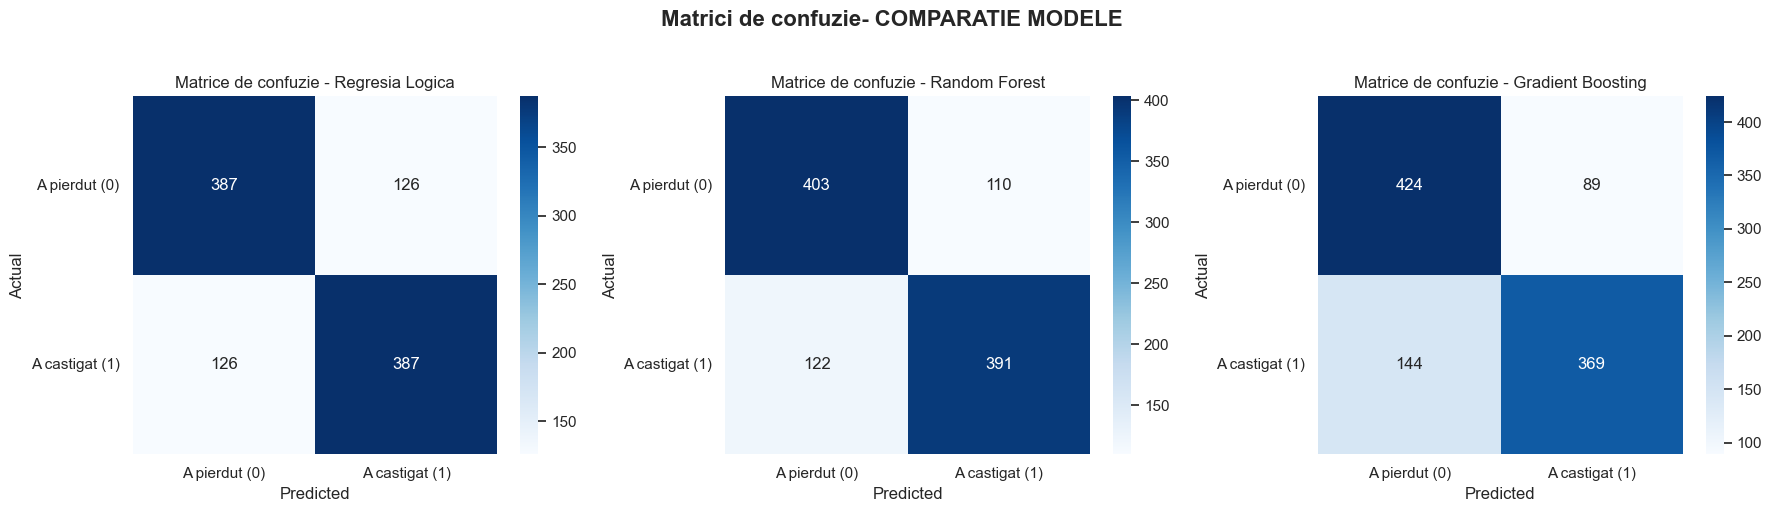

In [17]:
#matrici de confuzie
#cream lista care contine numele fiecarui model
models_info = [('Regresia Logica', y_pred_rl), ('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]

#pregatim mediul pt matrice
fig, axes = plt.subplots(1, len(models_info), figsize=(6 * len(models_info), 5))

if len(models_info) == 1:
    axes = [axes]  # asiguram ca axes este intotdeauna o lista, chiar daca avem un singur model

#asignam valorile matricii de confuzie pentru fiecare model
for ax, (name, y_pred) in zip(axes, models_info):
    #calculam matricea de confuzie
    cm = confusion_matrix(y_test, y_pred)

    #desenm matricea
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)

    #adaugam titlu si etichete
    ax.set_title(f'Matrice de confuzie - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['A pierdut (0)', 'A castigat (1)'])
    ax.set_yticklabels(['A pierdut (0)', 'A castigat (1)'], rotation=0)

#titlu mare
plt.suptitle('Matrici de confuzie- COMPARATIE MODELE', fontsize=16, fontweight='bold', y=1.02)
#reanranjam spatiul
plt.tight_layout()
#afisam matricile
plt.show()

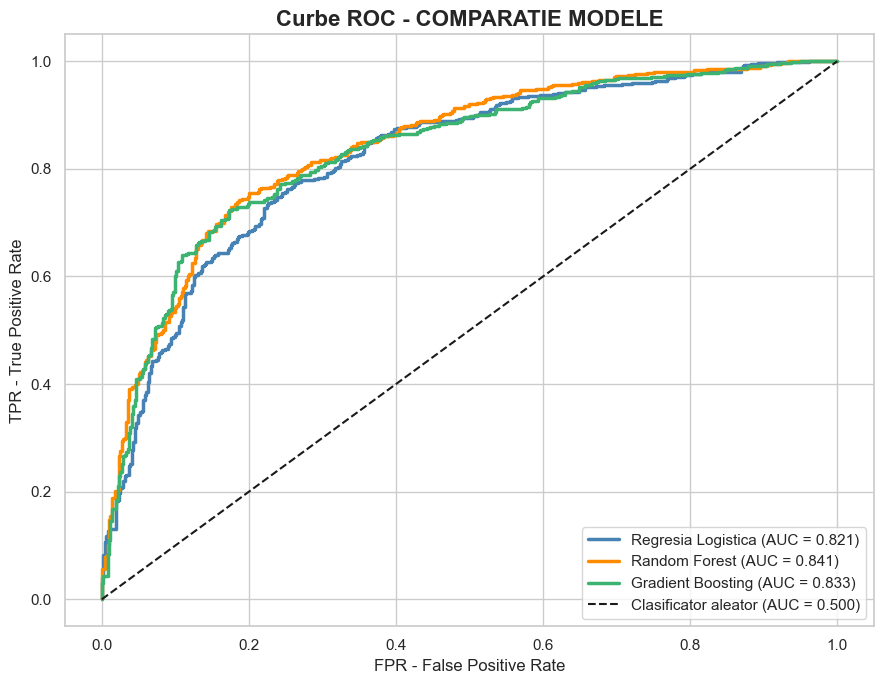

In [18]:
#vizualizarea curbelor ROC
fig, ax = plt.subplots(figsize=(9, 7))

#lista de culori pe care le atribuim fiecarui model
colors = ['steelblue', 'darkorange', 'mediumseagreen']

#cream lista cu modelele
roc_models = [('Regresia Logistica', rl_final), ('Random Forest', rf_final), ('Gradient Boosting', gb_final)]

#trecem prin lista de modele si culori 
for (name, model), color in zip(roc_models, colors):
    #calculam probabilitatile de predictie pt clasa pozitiva
    prob = model.predict_proba(X_test_sc)[:, 1]
    
    #calculam fpr, tpr si pragurile
    fpr, tpr, _ = roc_curve(y_test, prob)
    
    #calculam aria de sub curba
    roc_auc = auc(fpr, tpr)
    
    #desenam curba ROC
    ax.plot(fpr, tpr, lw=2.5,color=color, label=f'{name} (AUC = {roc_auc:.3f})')

#desenam linia de referinta
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificator aleator (AUC = 0.500)')

#etichetam axele si adaugam titlu
ax.set_xlabel('FPR - False Positive Rate', fontsize=12)
ax.set_ylabel('TPR - True Positive Rate', fontsize=12)

ax.set_title('Curbe ROC - COMPARATIE MODELE', fontsize=16, fontweight='bold')

#pozitionam legenda
ax.legend(loc='lower right', fontsize=11)

#asiguram aranajrea elementelor si afisarea graficului
plt.tight_layout()
plt.show()

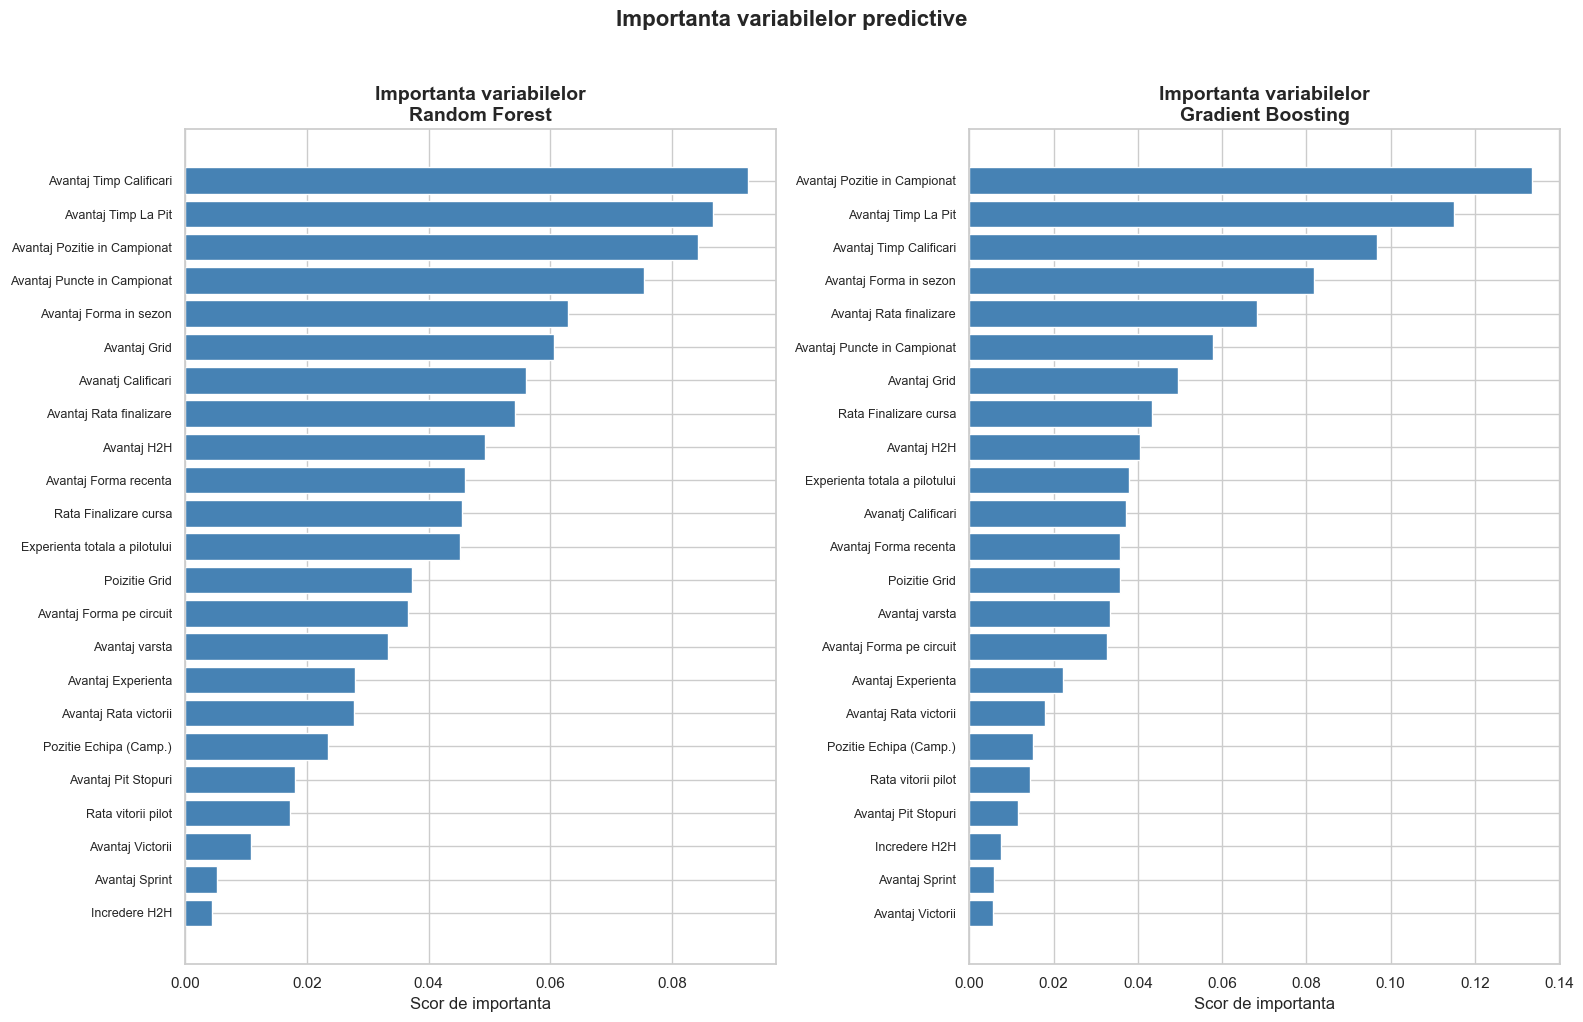

In [19]:
#importanta. variabilelor 

feature_labels = [
    'Poizitie Grid', 'Avantaj Grid', 'Avantaj varsta', 'Avanatj Calificari', 'Avantaj Timp Calificari',
    'Avantaj Puncte in Campionat', 'Avantaj Pozitie in Campionat', 'Avantaj Victorii', 'Pozitie Echipa (Camp.)', 
    'Avantaj Pit Stopuri', 'Avantaj Timp La Pit', 'Avantaj Sprint', 'Experienta totala a pilotului', 'Rata vitorii pilot',
    'Rata Finalizare cursa', 'Avantaj H2H', 'Avantaj Forma in sezon', 'Avantaj Experienta', 'Avantaj Rata victorii', 
    'Avantaj Rata finalizare', 'Incredere H2H', 'Avantaj Forma recenta', 'Avantaj Forma pe circuit'
]

imp_models = [('Random Forest', rf_final), ('Gradient Boosting', gb_final)]

if len(imp_models) == 1:
    axes= [axes] # asiguram ca axes este intotdeauna o lista, chiar daca avem un singur model

#cream figura
fig, axes = plt.subplots(1, len(imp_models), figsize=(16, 10))
#parcurgem fiecare model in parte
for ax, (name, model) in zip(axes, imp_models):
    #cream data frame temporar
    df_imp = pd.DataFrame({ 'Variabila': feature_labels, 'Importanta': model.feature_importances_})

    #sortam datele crescator
    df_imp = df_imp.sort_values('Importanta', ascending=True)

    #desenam bara orizontala
    ax.barh(df_imp['Variabila'], df_imp['Importanta'], color='steelblue', edgecolor='white')

    #titlu pt fiecare model
    ax.set_title(f'Importanta variabilelor\n{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Scor de importanta', fontsize=12) #impactul in luarea deciziilor

    #micsoram putin textul pe axa y pt vizibilitate
    ax.tick_params(axis='y', labelsize=9)

#titlu principal
plt.suptitle('Importanta variabilelor predictive', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

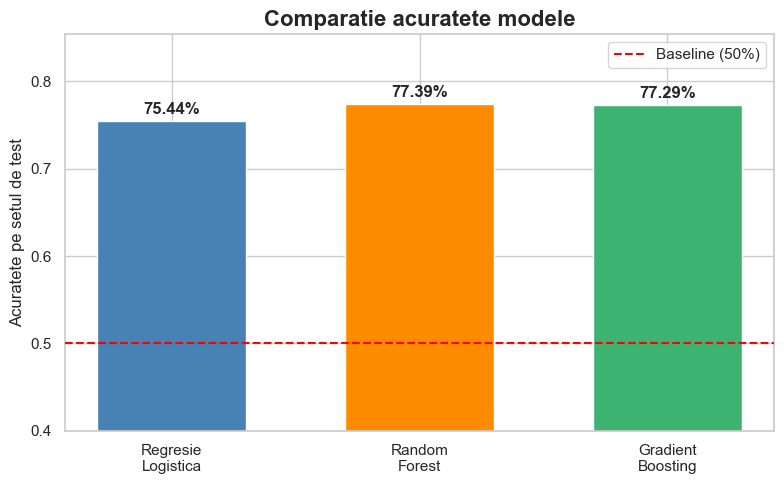

In [20]:
#acuratete comparativa (bar chart)

#definim listele de baza pt grafic
bar_names = ['Regresie\nLogistica', 'Random\nForest', 'Gradient\nBoosting']
bar_accs = [acc_rl, acc_rf, acc_gb]

#initializam grafic
fig, ax = plt.subplots(figsize=(8, 5))

#desenam barele
bars = ax.bar(bar_names, bar_accs, color=['steelblue', 'darkorange', 'mediumseagreen'][:len(bar_names)], edgecolor='white', width=0.6)

#parcurgem fiecare bar desenat
for bar, acc in zip(bars, bar_accs):
    #pozitionarea textului
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

#model complet aleatoriu
ax.axhline(0.5, color='red', linestyle='--', lw=1.5, label='Baseline (50%)', zorder=5)

#setam limitele pt axa y 
ax.set_ylim([0.4, min(1.0, max(bar_accs) +0.08)])

#etichetele si titlu
ax.set_ylabel('Acuratete pe setul de test', fontsize=12)
ax.set_title('Comparatie acuratete modele', fontsize=16, fontweight='bold')

#afisam legenda
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

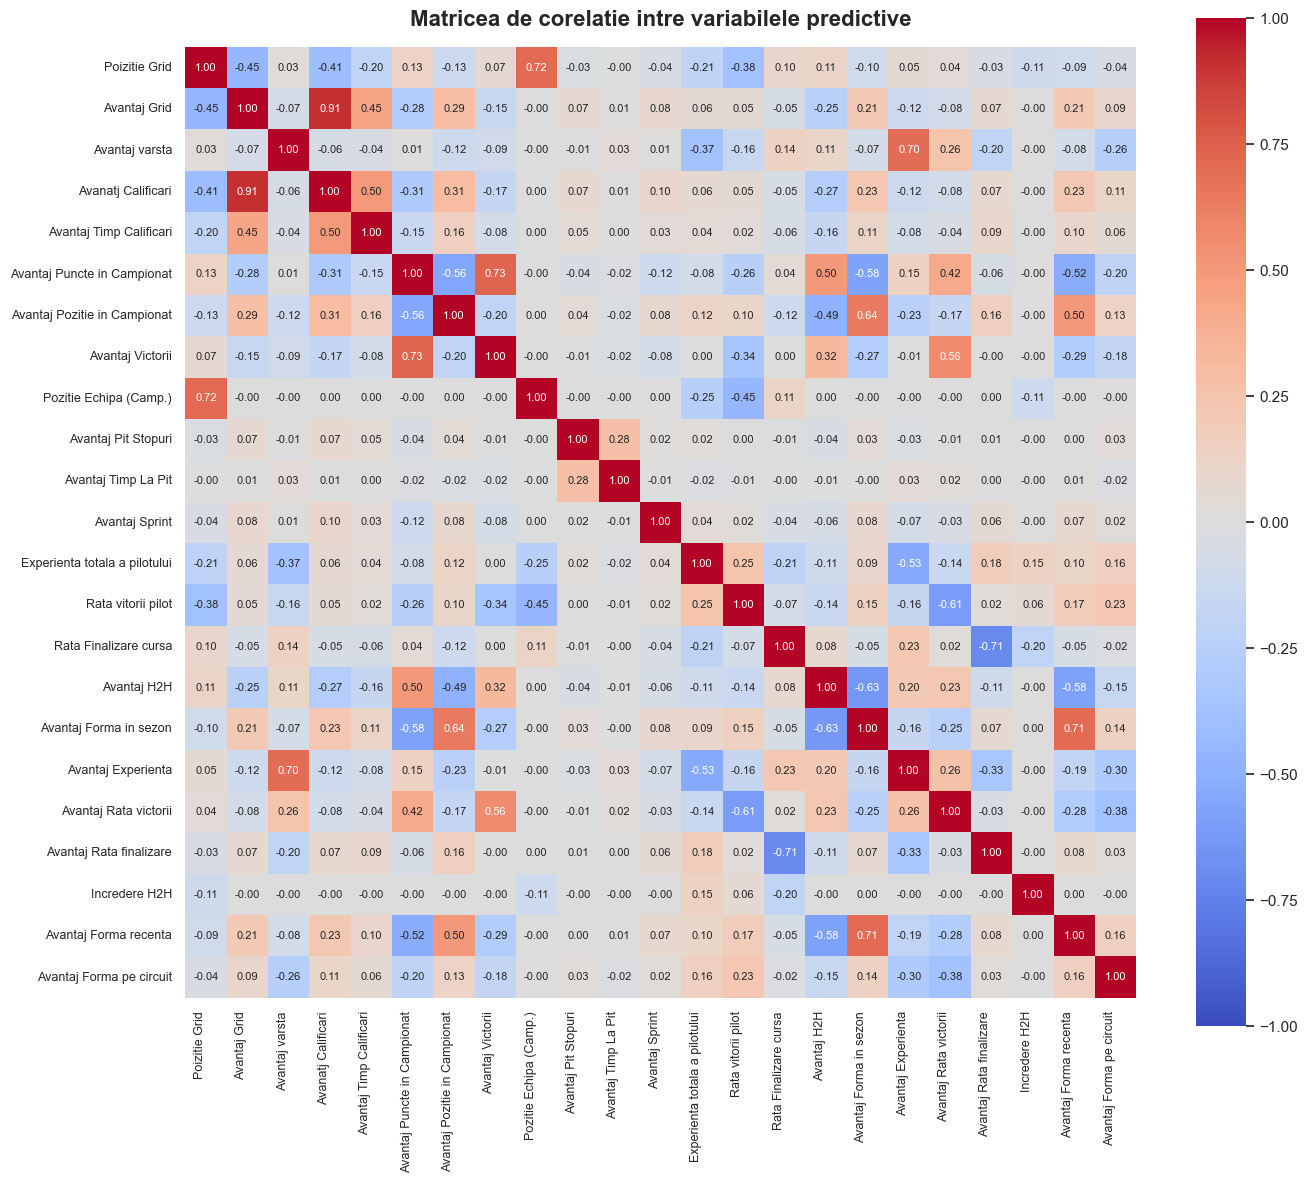

In [21]:
#heatmap cu corelatiile dintre variabilelle

#initializam figura
fig, ax = plt.subplots(figsize=(14, 12))

corr_matrix = df_ml[FEATURES].corr()

#inlocuim numele tehnice cu cele atribuite mai sus  in romana variabilelor
corr_matrix.columns = feature_labels
corr_matrix.index = feature_labels

#desenam heatmap ul
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, annot_kws={'size': 8}, ax=ax)

#titlu grafuului
ax.set_title('Matricea de corelatie intre variabilele predictive', fontsize=16, fontweight='bold', pad=15)

#aranjam etichetele
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
#rezumat si concluzii

print('REZUMAT F1 TEAMMATE BATTLE PREDICTION\n')

#metadatele proiectului si anii analizati
print(f' Dataset: Formula 1 Race Data (jtrorman, Kaggle v119)')
print(f' Perioada analizata: 2014-2026 (era V6 turno hibrid)')
print()
#volum de date procesate
print(f' Total exemple: {len(df_ml)}')
print(f' Variabile: {len(FEATURES)}')
print()

#acuratetile pt fiecare model
print(f' Regresia Logistica: {acc_rl:.2%}')
print(f' Random Forest: {acc_rf:.2%}')
print(f' Gradient Boosting: {acc_gb:.2%}')
best_acc = max(acc_rl, acc_rf, acc_gb)
best_name = ['Regresie Logistica', 'Random Forest', 'Gradient Boosting'][[acc_rl, acc_rf, acc_gb].index(best_acc)]
print(f'\n Cel mai bun model: {best_name} ({best_acc:.2%})')

REZUMAT F1 TEAMMATE BATTLE PREDICTION

 Dataset: Formula 1 Race Data (jtrorman, Kaggle v119)
 Perioada analizata: 2014-2026 (era V6 turno hibrid)

 Total exemple: 5050
 Variabile: 23

 Regresia Logistica: 75.44%
 Random Forest: 77.39%
 Gradient Boosting: 77.29%

 Cel mai bun model: Random Forest (77.39%)


In [23]:
import joblib

print('\nSALVARE DATE PENTRU APLICATIA WEB...')

# Selectează obiectul modelului câștigător
if best_name == 'Regresie Logistica':
    best_model_obj = rl_final
elif best_name == 'Random Forest':
    best_model_obj = rf_final
else:
    best_model_obj = gb_final

# Salvează modelul și preprocesoarele
joblib.dump(best_model_obj, 'best_f1_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')

# Salvează datele procesate (pentru a putea selecta curse și echipe din interfață)
df_pairs.to_csv('f1_ready_data.csv', index=False)

print('Totul a fost salvat cu succes!')


SALVARE DATE PENTRU APLICATIA WEB...
Totul a fost salvat cu succes!
